## Step 1: Load each CSV

In [1]:
import pandas as pd

categories = pd.read_csv('categories.csv')
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
order_details = pd.read_csv('order_details.csv')
products = pd.read_csv('products.csv')

## Step 2: Look at each one individually

In [2]:
for name, df in [('categories', categories), ('customers', customers),
                ('orders', orders), ('order_details', order_details),
                ('products', products)]:
    print(f"--- {name} ---")
    print(df.shape)
    print(df.head())
    print()

--- categories ---
(10, 2)
  CategoryID    CategoryName
0  CTGRY0001  Meat & Poultry
1  CTGRY0002    Dairy & Eggs
2  CTGRY0003         Produce
3  CTGRY0004       Beverages
4  CTGRY0005          Bakery

--- customers ---
(1000, 7)
  CustomerID  Gender  Age      City   Region CustomerSegment  SignUpDate
0  CSTMR0001    Male   29  Istanbul  Marmara        Standard  2020-04-13
1  CSTMR0002   Other   40  Istanbul  Marmara        Standard  2020-04-08
2  CSTMR0003  Female   36     Bursa  Marmara         Premium  2022-08-14
3  CSTMR0004    Male   18  Istanbul  Marmara         Premium  2022-03-26
4  CSTMR0005    Male   43     Izmir   Aegean         Premium  2021-04-04

--- orders ---
(10000, 4)
    OrderID CustomerID   OrderDate OrderTime
0  ORD00001  CSTMR0983  2021-04-10  12:53:24
1  ORD00002  CSTMR0703  2024-04-21  22:08:16
2  ORD00003  CSTMR0920  2022-10-27  10:21:26
3  ORD00004  CSTMR0158  2025-11-07  22:24:27
4  ORD00005  CSTMR0834  2021-09-05  13:23:16

--- order_details ---
(30271, 10)


## Step 3: Also open the .db file -- this uses your SQL knowledge directly

In [3]:
import sqlite3

# This opens a connection to the .df file(similar to connecting to MySQL)
conn = sqlite3.connect('retail_store.db')

# See what tables exist inside it
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print(tables)

            name
0     categories
1       products
2      customers
3         orders
4  order_details


### Step explained

- **sqlite3.connect('retail_store.db')** -- this opens a connection to the .db file, similar to how you'd connect to MySQL with a username/password, except SQLite databases are just a single file on disk -no server, no login needed. Conn is now your "pipe" to that database.
- **sqlite_master** -- this is a special built-in table that every SQLite database automatically has. It stores metadata about listing of every table, index, and view inside it.
- **pd.read_sql(...)** -- instead of manually running the query and looping through results, this pandas functiion runs the SQL query and immediately hands you back the result as a dataframe -- combining SQL and pandas in one step

## Step 4: Peek at each table's structure using SQL

In [4]:
query = """
SELECT * FROM orders LIMIT 5;
"""

pd.read_sql(query, conn)

,OrderID,CustomerID,OrderDate,OrderTime
0,ORD00001,CSTMR0983,2021-04-10,12:53:24
1,ORD00002,CSTMR0703,2024-04-21,22:08:16
2,ORD00003,CSTMR0920,2022-10-27,10:21:26
3,ORD00004,CSTMR0158,2025-11-07,22:24:27
4,ORD00005,CSTMR0834,2021-09-05,13:23:16


### Step explained  

- **SELECT * FROM orders** -- standard SQL: grab every column from the orders table.
- **LIMIT 5** -- only return 5 rows, just to peek at the structure without pulling the entire table.
- **pd.read_sql(query, conn)** -- runs the query against the same connection from Step 3, and returns it as a pandas dataframe you can view/manipulate normally.

The purpose: once we know a table's name (from Step 3), we look inside it to see its actual columns and sample data -- this tells us how it might connect to the CSV files you already loaded (e.g,**if orders has a customer_id** column, that's the link to your **customers.csv**)

In [5]:
query = "SELECT * FROM order_details LIMIT 5;"
pd.read_sql(query, conn)

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,None
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,None
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,None
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,None
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,None


In [6]:
query = """
SELECT o.OrderID, o.OrderDate, c.CustomerID, c.City, c.CustomerSegment
FROM orders o
JOIN customers c ON o.CustomerID = c.CustomerID
LIMIT 10;
"""

pd.read_sql(query, conn)

,OrderID,OrderDate,CustomerID,City,CustomerSegment
0,ORD00001,2021-04-10,CSTMR0983,Istanbul,Standard
1,ORD00002,2024-04-21,CSTMR0703,Istanbul,Standard
2,ORD00003,2022-10-27,CSTMR0920,Ankara,Standard
3,ORD00004,2025-11-07,CSTMR0158,Ankara,VIP
4,ORD00005,2021-09-05,CSTMR0834,Istanbul,VIP
5,ORD00006,2024-02-01,CSTMR0336,Ankara,Standard
6,ORD00007,2025-09-10,CSTMR0166,Aydin,Premium
7,ORD00008,2026-04-14,CSTMR0102,Kocaeli,Premium
8,ORD00009,2024-07-20,CSTMR0271,Bursa,Standard
9,ORD00010,2022-02-05,CSTMR0678,Ankara,Standard


So the relationship chain is:  
customers -> orders -> order_details -> products -> categories

## Step 5: Look inside order_details (from the database)

In [7]:
query = "SELECT * FROM order_details LIMIT 5;"
pd.read_sql(query, conn)

,OrderID,ProductID,Quantity,UnitCost,UnitPrice,DiscountRate,IsReturned,ReturnDate,ReturnTime,ReturnReason
0,ORD00001,PRDCT0056,3,2.14,3.38,0.00,0,9999-12-31,00:00:00,None
1,ORD00002,PRDCT0028,2,4.17,5.31,0.00,0,9999-12-31,00:00:00,None
2,ORD00002,PRDCT0001,13,20.36,25.77,0.05,0,9999-12-31,00:00:00,None
3,ORD00003,PRDCT0030,2,0.90,1.35,0.00,0,9999-12-31,00:00:00,None
4,ORD00004,PRDCT0003,3,12.84,20.35,0.00,0,9999-12-31,00:00:00,None


- **What this does:** connects to **retail_store.db**, and pull the first 5 rows from the order_detaills table so we can see its columns and sample data. 

Let's break down what each column means, since this table is the heart of your dataset (it's where the actual transactions live).

### Understanding order_details
- **OrderID** ->	Which order this line belongs to (links to orders table)
- **ProductID** ->	Which product was bought (links to products table)
- **Quantity** ->	How many units were bought
- **UnitCost** ->	What it cost the store to acquire one unit (their cost price)
- **UnitPrice** ->	What the customer was charged per unit (selling price)
- **DiscountRate** ->	Any discount applied (0.05 = 5% off)
- **IsReturned** ->	0 = not returned, 1 = returned
- **ReturnDate / ReturnTime** ->	When it was returned (notice 9999-12-31 — this is a placeholder meaning "not returned," not a real date)
- **ReturnReason** ->	Why it was returned (None here, since nothing was returned in these rows)

**One important thing to notice:** each row here is one **product line** within an order, not one order, ie OrderID **ORD00002** - it appears twice, because that single order contained two different products.

### Step 6: First JOIN - connect orders to customers

In [8]:
query = """
SELECT o.OrderID, o.OrderDate, c.CustomerID, c.City, c.CustomerSegment
FROM orders o
JOIN customers c ON o.CustomerID = c.CustomerID
LIMIT 10;
"""
pd.read_sql(query, conn)

,OrderID,OrderDate,CustomerID,City,CustomerSegment
0,ORD00001,2021-04-10,CSTMR0983,Istanbul,Standard
1,ORD00002,2024-04-21,CSTMR0703,Istanbul,Standard
2,ORD00003,2022-10-27,CSTMR0920,Ankara,Standard
3,ORD00004,2025-11-07,CSTMR0158,Ankara,VIP
4,ORD00005,2021-09-05,CSTMR0834,Istanbul,VIP
5,ORD00006,2024-02-01,CSTMR0336,Ankara,Standard
6,ORD00007,2025-09-10,CSTMR0166,Aydin,Premium
7,ORD00008,2026-04-14,CSTMR0102,Kocaeli,Premium
8,ORD00009,2024-07-20,CSTMR0271,Bursa,Standard
9,ORD00010,2022-02-05,CSTMR0678,Ankara,Standard


**Why this matters:** on its own, orders only shows you a CustomerID code like CSTMR0983 - meaningless without context. This join lets you see where that customer is from and what segment they belong to, right alongside their order.  

The real power is this: you can now group and filter by things that weren't originally attached to orders at all.  

For example, with this joined view you could now ask:
- "Which city generate the most orders"
- "Do VIP customers order more often than Standard customers"
- "Is there a region where sales are growing or shrinking?"

None of those questions were answerabel from orders alone - you needed customers' columns attached to make them askable. That's the core idea: joining doesn't just add columns for decoration, it unlocks entirely new questions you can ask of the data.

In [9]:
tables

,name
0,categories
1,products
2,customers
3,orders
4,order_details


### Step 7:A biggener join - revenue per product category

In [10]:
query = """
SELECT cat.CategoryName,
        SUM(od.Quantity * od.UnitPrice) AS TotalRevenue
FROM order_details od
JOIN products p ON od.ProductID = p.ProductID
JOIN categories cat ON p.CategoryID = cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY TotalRevenue DESC;
"""
pd.read_sql(query, conn)

,CategoryName,TotalRevenue
0,Meat & Poultry,261741.02
1,Personal Care,98854.72
2,Household Cleaning,89750.36
3,Dairy & Eggs,73815.43
4,Pantry Staples,56547.31
5,Snacks,53614.21
6,Beverages,45737.14
7,Produce,41912.28
8,Frozen Foods,39458.61
9,Bakery,30501.39


### Next step - customer spending using pandas instead of SQL

In [12]:
customers_orders = orders.merge(order_details, on='OrderID')
customers_orders['Revenue'] = customers_orders['Quantity'] * customers_orders['UnitPrice']

top_customers = customers_orders.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
CSTMR0127    3396.19
CSTMR0959    3138.23
CSTMR0834    3000.41
CSTMR0806    2855.30
CSTMR0104    2754.91
CSTMR0768    2745.87
CSTMR0535    2735.62
CSTMR0573    2725.78
CSTMR0990    2715.43
CSTMR0964    2702.74
Name: Revenue, dtype: float64


### Briefly:  
- **merge()** = pandas' version of JOIN (connects orders+order_details on OrderID)
- **.groupby('CustomerID')** = same as SQL's GROUP BY
- **.sort_values() + .head(10)** = top 10 spenders

Result: **CSTMR0127** is the top spender at $3,396.19 — but notice how close the rest of the top 10 are (mostly $2,700–$3,100), suggesting no single customer dominates spending.

### Next step — add customer details to these top spenders (merge with customers table)

In [14]:
top_customers_df = top_customers.reset_index()
top_customers_full = top_customers_df.merge(customers, on='CustomerID')
print(top_customers_full)

  CustomerID  Revenue  Gender  Age       City            Region  \
0  CSTMR0127  3396.19  Female   29   Istanbul           Marmara   
1  CSTMR0959  3138.23  Female   29      Bursa           Marmara   
2  CSTMR0834  3000.41    Male   38   Istanbul           Marmara   
3  CSTMR0806  2855.30  Female   43  Eskisehir  Central Anatolia   
4  CSTMR0104  2754.91    Male   39     Ankara  Central Anatolia   
5  CSTMR0768  2745.87    Male   50   Istanbul           Marmara   
6  CSTMR0535  2735.62  Female   44   Istanbul           Marmara   
7  CSTMR0573  2725.78  Female   21      Izmir            Aegean   
8  CSTMR0990  2715.43  Female   35     Ankara  Central Anatolia   
9  CSTMR0964  2702.74  Female   40     Ankara  Central Anatolia   

  CustomerSegment  SignUpDate  
0             VIP  2022-12-08  
1             VIP  2022-06-24  
2             VIP  2020-08-01  
3             VIP  2022-05-11  
4         Premium  2022-05-22  
5             VIP  2022-07-29  
6             VIP  2021-05-19  
7     

### Briefly:  

- **.reset_index()** turns the CustomerID from an index back into a normal column (needed to merge)
- **.merge(customers, on='CustomerID')** attaches City, Segement, Age, etc. to each top spender.

### Now we can visualize category revenue as a chart

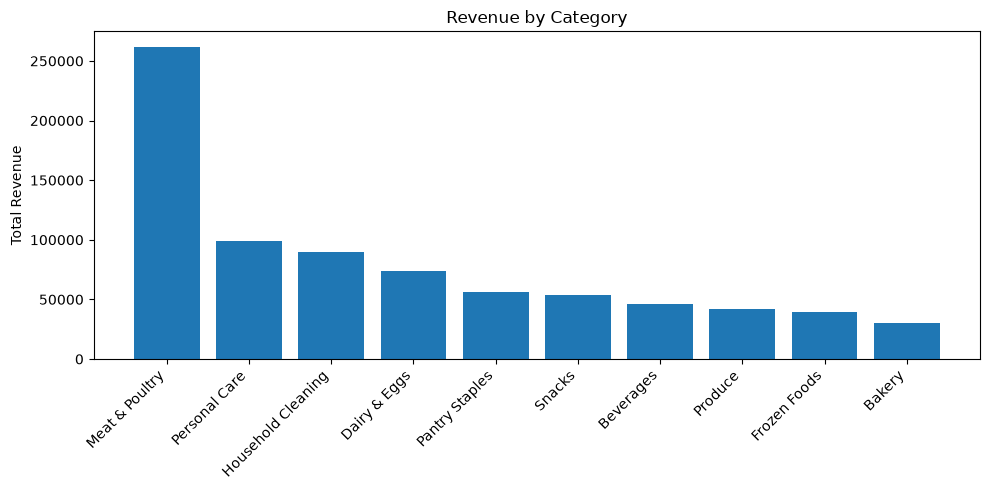

In [16]:
import matplotlib.pyplot as plt

category_revenue = pd.read_sql(query, conn)

plt.figure(figsize=(10, 5))
plt.bar(category_revenue['CategoryName'], category_revenue['TotalRevenue'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Revenue')
plt.title('Revenue by Category')
plt.tight_layout()
plt.show()

Meat & Poultry towere over every other category - visually confirms  

### How it connects to top spenders:  

These are two different "slices" of the same underlying data (order_details), just grouped differently:  

- This chart = grouped by CategoryName -> shows what sells best overall
- Top spenders table = grouped by CustomerID -> shows who spends the most overall

They're not directly linked yet - you don't know if the top spender (CSTMR0127) actually bought Meat&Poultry specifically. To connect them, we'd need a new query grouping by both category AND customer.  

### See what CSTMR0127(#1 spender) actually bought:

In [19]:
query = f"""
SELECT cat.CategoryName, SUM(od.Quantity * od.UnitPrice) AS Spent
FROM order_details od
JOIN orders o ON od.OrderID = o.OrderID
JOIN products p ON od.ProductID = p.ProductID
JOIN categories cat ON p.CategoryID = cat.CategoryID
WHERE o.CustomerID = 'CSTMR0127'
GROUP BY cat.CategoryName
ORDER BY Spent DESC;
"""
pd.read_sql(query, conn)

,CategoryName,Spent
0,Meat & Poultry,2303.27
1,Personal Care,367.07
2,Pantry Staples,227.04
3,Household Cleaning,124.66
4,Dairy & Eggs,115.78
5,Produce,67.75
6,Bakery,57.38
7,Beverages,48.99
8,Snacks,43.44
9,Frozen Foods,40.81
